# Multi-Agent System for Problem Solving

## Overview

This system represents a collaboration of multiple agents—Business, Student, Teacher, and Teaching Assistant—to solve problems effectively. Each agent plays a unique role in the process, working in tandem to reach optimal solutions. The flowchart describes how tasks and responsibilities are distributed among these agents.

---

## Entities and Their Roles

### **Business Entity**
The Business entity defines the problems and evaluates solutions to ensure they meet desired outcomes.

**Key Steps:**
1. **Problem Statement:** Define the problem and communicate it to the Student Agent.
2. **Evaluate Solution:** Assess submitted solutions based on defined criteria.
3. **Grade Based on Results:** Assign grades or feedback based on solution performance.

---

### **Student Agent**
The Student agent is responsible for problem-solving, leveraging guidance from other agents when needed.

**Key Steps:**
1. **Receive Problem:** Accepts the problem from the Business entity.
2. **Convert to Analytical Problem:** Reformulates the problem into an analytical framework.
3. **Attempt Solution:** Tries solving the problem independently.
4. **Implement Solution:** Transforms theoretical solutions into practical implementations.
5. **Final Solution:** Develops a polished solution for submission.
6. **Validation Decision:** Decides whether to seek validation from the Teacher Agent.

---

### **Teacher Agent**
The Teacher agent provides general knowledge, tracks questions, and validates solutions to ensure their accuracy and relevance.

**Key Steps:**
1. **Knowledge Base:** Maintains expertise in the subject domain.
2. **Track Questions:** Monitors the quality and relevance of questions posed by the Student Agent.
3. **Provide Broad Guidance:** Offers general advice when the Student encounters challenges.
4. **Grade Student:** Assesses Student performance for learning purposes.
5. **Validate Solution:** Reviews and validates the final solution submitted by the Student.

---

### **Teaching Assistant Agent**
The Teaching Assistant agent focuses on specific tasks and supports the Student with task-specific guidance.

**Key Steps:**
1. **Specific Task Knowledge:** Possesses expertise in targeted areas of the problem.
2. **Track Progress:** Monitors the Student's progress on specific tasks.
3. **Task-Specific Guidance:** Provides detailed, actionable advice tailored to particular challenges.
4. **Grade Student:** Assesses task-specific outcomes.

---

## Process Flow

### 1. Problem Assignment
- The **Business** entity assigns the problem to the **Student Agent**.

### 2. Problem Analysis and Attempt
- The **Student Agent** reformulates the problem analytically and begins solving it.
- If the Student gets stuck, they may seek:
  - **Broad Guidance** from the **Teacher Agent**.
  - **Specific Guidance** from the **Teaching Assistant Agent**.

### 3. Solution Implementation and Validation
- Once the solution is developed, the Student decides whether to:
  - Request validation from the **Teacher Agent**.
  - Submit directly to the **Business Entity** for evaluation.

### 4. Evaluation and Feedback
- The **Business Entity** evaluates the solution and provides feedback or grades.
- Meanwhile, the **Teacher Agent** and **Teaching Assistant Agent** track the quality of questions and progress for grading purposes.

---

## Collaboration Highlights

- **Human-in-the-loop:** The Student Agent engages dynamically with the Teacher and TA agents, ensuring robust problem-solving.
- **Parallel Guidance:** Both Teacher and TA agents provide complementary support to the Student for a holistic learning process.
- **Feedback Loop:** Continuous evaluation by Business and Teacher agents refines the overall system performance.

This multi-agent system ensures a streamlined, efficient, and collaborative approach to tackling complex problems.


# Setup

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o", temperature=0) 

# Code for Business and Student

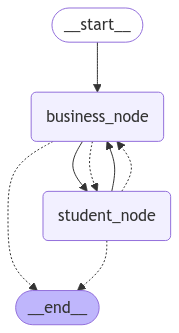

In [17]:
import uuid
from datetime import datetime
from typing import Optional, Literal, Dict, Any
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
from langgraph.store.base import BaseStore

# Initialize the model
model = ChatOpenAI(model="gpt-4", temperature=0)

# Schema Definitions
class Problem(BaseModel):
    problem_id: str = Field(description="Unique identifier for the problem")
    description: str = Field(description="Problem statement")
    requirements: list[str] = Field(description="List of requirements")
    difficulty: str = Field(description="Problem difficulty level")
    domain: str = Field(description="Problem domain/subject")
    max_attempts: int = Field(description="Maximum allowed attempts")
    solution_criteria: list[str] = Field(description="Criteria for evaluating solutions")

class Solution(BaseModel):
    solution_id: str = Field(description="Unique identifier for the solution")
    problem_id: str = Field(description="Reference to the problem")
    approach: str = Field(description="Analytical approach taken")
    implementation: str = Field(description="Actual implementation details")
    status: Literal["draft", "implementing", "completed", "validated", "graded"] = Field(
        default="draft"
    )
    attempts: int = Field(default=0)
    feedback: list[str] = Field(default_factory=list)
    grade: Optional[float] = Field(default=None)

class Grade(BaseModel):
    grade_id: str = Field(description="Unique identifier for the grade")
    solution_id: str = Field(description="Reference to the solution")
    score: float = Field(description="Numerical score (0-100)")
    feedback: str = Field(description="Detailed feedback")
    graded_at: datetime = Field(default_factory=datetime.now)

class ConversationState(BaseModel):
    is_completed: bool = Field(default=False, description="Flag to indicate if conversation should end")
    turn_count: int = Field(default=0, description="Counter for conversation turns")
    max_turns: int = Field(default=3, description="Maximum allowed conversation turns")

# Business Entity Node
def business_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    problems_namespace = ("problems", user_id)
    solutions_namespace = ("solutions", user_id)
    grades_namespace = ("grades", user_id)
    
    # Get or initialize conversation state
    conv_state_key = ("conversation_state", config["configurable"]["thread_id"])
    try:
        conv_state_data = store.get(conv_state_key)
    except (KeyError, AttributeError):
        conv_state_data = None
    
    if conv_state_data is None:
        conv_state = ConversationState()
    else:
        conv_state = ConversationState(**conv_state_data)
    
    # Increment turn counter
    conv_state.turn_count += 1
    if conv_state.turn_count >= conv_state.max_turns:
        conv_state.is_completed = True
    
    system_prompt = """You are a business entity that creates and evaluates problem statements.
    When creating problems, include specific evaluation criteria.
    When grading solutions:
    1. Evaluate against specific criteria provided in the problem
    2. Consider multiple aspects: correctness, efficiency, methodology
    3. Provide detailed feedback for each criterion
    4. Assign appropriate scores based on performance (0-100):
       - 90-100: Exceptional, goes beyond requirements
       - 80-89: Meets all requirements effectively
       - 70-79: Meets most requirements with minor issues
       - 60-69: Meets basic requirements with some issues
       - Below 60: Significant improvements needed
    Be critical and realistic in scoring."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    try:
        # Store updated conversation state
        store.put(conv_state_key, conv_state.model_dump())
    except AttributeError:
        # Handle case where store doesn't support put operation
        pass
    
    if "create_problem" in response.content.lower():
        problem = Problem(
            problem_id=str(uuid.uuid4()),
            description=response.content,
            requirements=["Clear approach", "Correct implementation", "Efficient solution"],
            difficulty="medium",
            domain="general",
            max_attempts=3,
            solution_criteria=["Correctness", "Efficiency", "Code quality"]
        )
        try:
            store.put(problems_namespace, problem.problem_id, problem.model_dump())
        except AttributeError:
            pass
            
        return {
            "messages": [response], 
            "current_problem": problem.problem_id,
            "is_completed": conv_state.is_completed
        }
    
    # Modified grading logic
    if "grade_solution" in response.content.lower() and "current_solution" in state:
        try:
            solution_data = store.get(solutions_namespace, state["current_solution"])
        except (KeyError, AttributeError):
            solution_data = None
            
        if solution_data:
            solution = Solution(**solution_data)
            
            # Extract score using more robust parsing
            score = extract_score(response.content)
            
            grade = Grade(
                grade_id=str(uuid.uuid4()),
                solution_id=solution.solution_id,
                score=score,
                feedback=response.content
            )
            
            solution.status = "graded"
            solution.grade = score
            solution.feedback.append(grade.feedback)
            
            try:
                store.put(grades_namespace, grade.grade_id, grade.model_dump())
                store.put(solutions_namespace, solution.solution_id, solution.model_dump())
            except AttributeError:
                pass
            
            return {
                "messages": [response], 
                "grade": grade.model_dump(),
                "is_completed": conv_state.is_completed
            }
    
    return {"messages": [response], "is_completed": conv_state.is_completed}


# Student Node
def student_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    problems_namespace = ("problems", user_id)
    solutions_namespace = ("solutions", user_id)
    
    system_prompt = """You are a student agent that:
    1. Analyzes problems
    2. Converts them to analytical format
    3. Attempts solutions
    4. Implements and validates them
    Provide detailed explanations of your approach."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if "submit_solution" in response.content.lower() and "current_problem" in state:
        solution = Solution(
            solution_id=str(uuid.uuid4()),
            problem_id=state["current_problem"],
            approach=response.content,
            implementation="Implementation details",
            status="completed"
        )
        try:
            store.put(solutions_namespace, solution.solution_id, solution.model_dump())
        except AttributeError:
            pass
            
        return {"messages": [response], "current_solution": solution.solution_id}
    
    return {"messages": [response]}

def extract_score(content: str) -> float:
    """
    Extract score from response content using multiple patterns and validation.
    """
    import re
    
    # Common patterns for score extraction
    patterns = [
        r"Score:\s*(\d+(?:\.\d+)?)/100",
        r"Grade:\s*(\d+(?:\.\d+)?)/100",
        r"Final score:\s*(\d+(?:\.\d+)?)",
        r"(\d+(?:\.\d+)?)\s*points out of 100",
    ]
    
    for pattern in patterns:
        match = re.search(pattern, content)
        if match:
            try:
                score = float(match.group(1))
                # Validate score range
                if 0 <= score <= 100:
                    return score
            except ValueError:
                continue
    
    # If no valid score found, analyze feedback sentiment and assign appropriate score
    feedback_lower = content.lower()
    if any(word in feedback_lower for word in ["excellent", "exceptional", "outstanding"]):
        return 90.0
    elif any(word in feedback_lower for word in ["good", "well done", "effective"]):
        return 80.0
    elif any(word in feedback_lower for word in ["satisfactory", "adequate"]):
        return 70.0
    elif any(word in feedback_lower for word in ["needs improvement", "issues"]):
        return 60.0
    else:
        return 65.0  # Default moderate score

# Modified route_message function
def route_message(state: MessagesState) -> str:
    if state.get("is_completed", False):
        return END
        
    message = state["messages"][-1]
    content = message.content.lower()
    
    if "grade" in content or "evaluate" in content:
        return "business_node"
    elif "solution" in content or "solve" in content:
        return "student_node"
    elif "problem" in content:
        return "business_node"
    
    return END

# Graph construction
builder = StateGraph(MessagesState)
builder.add_node("business_node", business_node)
builder.add_node("student_node", student_node)

# Define edges
builder.add_edge(START, "business_node")
builder.add_edge("business_node", "student_node")
builder.add_edge("student_node", "business_node")
builder.add_conditional_edges("business_node", route_message)
builder.add_conditional_edges("student_node", route_message)

# Compile graph
workflow = builder.compile()
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [ ]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory  
config = {"configurable": {"thread_id": "1", "user_id": "Lance"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="Create a problem about data structures")]

# Run the graph

for chunk in workflow.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()



================================ Human Message =================================

Create a problem about data structures
================================== Ai Message ==================================

Problem Statement:

Design and implement a data structure for a library system. The system should be able to perform the following operations efficiently:

1. Add a new book: The book details include title, author, publication year, and ISBN number. 

2. Search for a book: The user should be able to search for a book by title, author, or ISBN number. 

3. Remove a book: The system should be able to remove a book from the library using the ISBN number.

4. List all books: The system should be able to list all the books in the library.

Evaluation Criteria:

1. Correctness: The data structure should correctly implement all the required operations. 

2. Efficiency: The data structure should perform all operations in an efficient manner. The time complexity of each operation should be as lo

# Code for Student, Business and Teacher

In [14]:
import uuid
from datetime import datetime
from typing import Optional, Literal, Dict, Any
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
from langgraph.store.base import BaseStore

# Initialize the model
model = ChatOpenAI(model="gpt-4", temperature=0)

# Schema Definitions
class Problem(BaseModel):
    problem_id: str = Field(description="Unique identifier for the problem")
    description: str = Field(description="Problem statement")
    requirements: list[str] = Field(description="List of requirements")
    difficulty: str = Field(description="Problem difficulty level")
    domain: str = Field(description="Problem domain/subject")
    max_attempts: int = Field(description="Maximum allowed attempts")
    solution_criteria: list[str] = Field(description="Criteria for evaluating solutions")

class Solution(BaseModel):
    solution_id: str = Field(description="Unique identifier for the solution")
    problem_id: str = Field(description="Reference to the problem")
    approach: str = Field(description="Analytical approach taken")
    implementation: str = Field(description="Actual implementation details")
    status: Literal["draft", "implementing", "completed", "validated", "graded"] = Field(
        default="draft"
    )
    attempts: int = Field(default=0)
    feedback: list[str] = Field(default_factory=list)
    grade: Optional[float] = Field(default=None)
    needs_validation: bool = Field(default=False)
    validation_feedback: Optional[str] = Field(default=None)

class Grade(BaseModel):
    grade_id: str = Field(description="Unique identifier for the grade")
    solution_id: str = Field(description="Reference to the solution")
    score: float = Field(description="Numerical score (0-100)")
    feedback: str = Field(description="Detailed feedback")
    graded_at: datetime = Field(default_factory=datetime.now)

class TeacherGuidance(BaseModel):
    guidance_id: str = Field(description="Unique identifier for the guidance")
    problem_id: str = Field(description="Reference to the problem")
    student_id: str = Field(description="Reference to the student")
    guidance_type: Literal["broad", "validation"] = Field(description="Type of guidance provided")
    content: str = Field(description="Actual guidance content")
    provided_at: datetime = Field(default_factory=datetime.now)

class ConversationState(BaseModel):
    is_completed: bool = Field(default=False, description="Flag to indicate if conversation should end")
    turn_count: int = Field(default=0, description="Counter for conversation turns")
    max_turns: int = Field(default=3, description="Maximum allowed conversation turns")

# Business Entity Node
def business_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    problems_namespace = ("problems", user_id)
    solutions_namespace = ("solutions", user_id)
    grades_namespace = ("grades", user_id)
    
    system_prompt = """You are a business entity that creates and evaluates problem statements.
    When creating problems, include specific evaluation criteria.
    When grading solutions:
    1. Evaluate against specific criteria provided in the problem
    2. Consider multiple aspects: correctness, efficiency, methodology
    3. Provide detailed feedback for each criterion
    4. Assign appropriate scores based on performance (0-100)"""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if "create_problem" in response.content.lower():
        problem = Problem(
            problem_id=str(uuid.uuid4()),
            description=response.content,
            requirements=["Clear approach", "Correct implementation", "Efficient solution"],
            difficulty="medium",
            domain="general",
            max_attempts=3,
            solution_criteria=["Correctness", "Efficiency", "Code quality"]
        )
        try:
            store.put(problems_namespace, problem.problem_id, problem.model_dump())
        except AttributeError:
            pass
            
        return {
            "messages": [response], 
            "current_problem": problem.problem_id
        }
    
    if "grade_solution" in response.content.lower() and "current_solution" in state:
        try:
            solution_data = store.get(solutions_namespace, state["current_solution"])
        except (KeyError, AttributeError):
            solution_data = None
            
        if solution_data:
            solution = Solution(**solution_data)
            score = extract_score(response.content)
            
            grade = Grade(
                grade_id=str(uuid.uuid4()),
                solution_id=solution.solution_id,
                score=score,
                feedback=response.content
            )
            
            solution.status = "graded"
            solution.grade = score
            solution.feedback.append(grade.feedback)
            
            try:
                store.put(grades_namespace, grade.grade_id, grade.model_dump())
                store.put(solutions_namespace, solution.solution_id, solution.model_dump())
            except AttributeError:
                pass
            
            return {
                "messages": [response], 
                "grade": grade.model_dump()
            }
    
    return {"messages": [response]}

# Student Node
def student_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    solutions_namespace = ("solutions", user_id)
    
    system_prompt = """You are a student agent that:
    1. Analyzes problems and converts them to analytical format
    2. Attempts solutions with implementation
    3. Can request guidance when stuck
    4. Can submit solutions for validation
    Explain your approach and indicate when you need help."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if "need_guidance" in response.content.lower():
        return {"messages": [response], "needs_guidance": True}
    
    if "submit_solution" in response.content.lower() and "current_problem" in state:
        solution = Solution(
            solution_id=str(uuid.uuid4()),
            problem_id=state["current_problem"],
            approach=response.content,
            implementation="Implementation details",
            status="completed",
            needs_validation=True
        )
        try:
            store.put(solutions_namespace, solution.solution_id, solution.model_dump())
        except AttributeError:
            pass
            
        return {"messages": [response], "current_solution": solution.solution_id}
    
    return {"messages": [response]}

# Teacher Node
def teacher_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    guidance_namespace = ("guidance", user_id)
    solutions_namespace = ("solutions", user_id)
    
    system_prompt = """You are a teacher agent that:
    1. Maintains a knowledge base of the subject
    2. Provides broad guidance when students are stuck
    3. Validates solutions before final submission
    4. Tracks student questions and progress
    Give constructive feedback and guide students toward solutions without providing direct answers."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if state.get("needs_guidance", False):
        guidance = TeacherGuidance(
            guidance_id=str(uuid.uuid4()),
            problem_id=state.get("current_problem", ""),
            student_id=user_id,
            guidance_type="broad",
            content=response.content
        )
        try:
            store.put(guidance_namespace, guidance.guidance_id, guidance.model_dump())
        except AttributeError:
            pass
            
        return {"messages": [response], "guidance_provided": True}
    
    if "current_solution" in state and state.get("needs_validation", False):
        try:
            solution_data = store.get(solutions_namespace, state["current_solution"])
            if solution_data:
                solution = Solution(**solution_data)
                solution.validation_feedback = response.content
                solution.needs_validation = False
                store.put(solutions_namespace, solution.solution_id, solution.model_dump())
        except (KeyError, AttributeError):
            pass
            
        return {"messages": [response], "validation_complete": True}
    
    return {"messages": [response]}

def extract_score(content: str) -> float:
    """Extract score from response content using multiple patterns and validation."""
    import re
    
    patterns = [
        r"Score:\s*(\d+(?:\.\d+)?)/100",
        r"Grade:\s*(\d+(?:\.\d+)?)/100",
        r"Final score:\s*(\d+(?:\.\d+)?)",
        r"(\d+(?:\.\d+)?)\s*points out of 100",
    ]
    
    for pattern in patterns:
        match = re.search(pattern, content)
        if match:
            try:
                score = float(match.group(1))
                if 0 <= score <= 100:
                    return score
            except ValueError:
                continue
    
    feedback_lower = content.lower()
    if any(word in feedback_lower for word in ["excellent", "exceptional", "outstanding"]):
        return 90.0
    elif any(word in feedback_lower for word in ["good", "well done", "effective"]):
        return 80.0
    elif any(word in feedback_lower for word in ["satisfactory", "adequate"]):
        return 70.0
    elif any(word in feedback_lower for word in ["needs improvement", "issues"]):
        return 60.0
    else:
        return 65.0

def route_message(state: MessagesState) -> str:
    message = state["messages"][-1]
    content = message.content.lower()
    
    if state.get("needs_guidance", False):
        return "teacher_node"
    
    if state.get("needs_validation", False):
        return "teacher_node"
    
    if "grade" in content or "evaluate" in content:
        return "business_node"
    elif "guidance" in content or "help" in content:
        return "teacher_node"
    elif "solution" in content or "solve" in content:
        return "student_node"
    elif "problem" in content:
        return "business_node"
    elif "validate" in content:
        return "teacher_node"
    
    return END

# Graph construction
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("business_node", business_node)
builder.add_node("student_node", student_node)
builder.add_node("teacher_node", teacher_node)

# Define edges
builder.add_edge(START, "business_node")
builder.add_edge("business_node", "student_node")
builder.add_edge("student_node", "business_node")
builder.add_edge("student_node", "teacher_node")
builder.add_edge("teacher_node", "student_node")
builder.add_edge("teacher_node", "business_node")

# Add conditional edges
builder.add_conditional_edges("business_node", route_message)
builder.add_conditional_edges("student_node", route_message)
builder.add_conditional_edges("teacher_node", route_message)

# Compile graph
workflow = builder.compile()

In [16]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory  
config = {"configurable": {"thread_id": "1", "user_id": "Lance"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="Create a problem about data structures")]

# Run the graph

for chunk in workflow.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()



================================ Human Message =================================

Create a problem about data structures
================================== Ai Message ==================================

Problem Statement:

Design and implement a data structure for a library system. The system should be able to perform the following operations efficiently:

1. Add a new book: The system should be able to add a new book with details such as title, author, genre, and publication year.

2. Search for a book: The system should be able to search for a book by title, author, or genre.

3. Remove a book: The system should be able to remove a book from the system.

4. List all books: The system should be able to list all the books in the library.

5. List books by genre: The system should be able to list all the books of a particular genre.

Evaluation Criteria:

1. Correctness (30 points): The data structure should correctly implement all the required operations.

2. Efficiency (30 points): Th

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4 in organization org-VJsSypREXwAv7Kl3RDr911dP on tokens per min (TPM): Limit 10000, Used 9441, Requested 3517. Please try again in 17.748s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

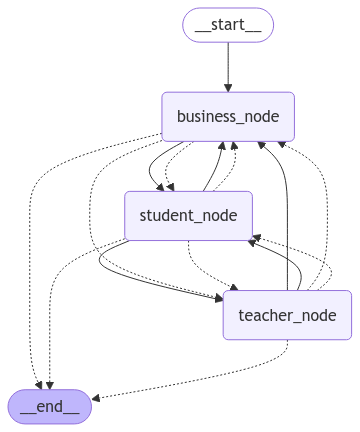

In [15]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [ ]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory  
config = {"configurable": {"thread_id": "1", "user_id": "Lance"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="Create a problem about data structures")]

# Run the graph

for chunk in workflow.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()



# Code for Student, Business, Teacher (with changings)

In [2]:
import uuid
from datetime import datetime
from typing import Optional, Literal, Dict, Any, List
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_openai import ChatOpenAI
from langgraph.store.base import BaseStore

model = ChatOpenAI(model="gpt-4", temperature=0)

# Helper function to create a prompt
def create_prompt(role, content):
    return f"{role}\n{content}\n"

# Problem schema
class Problem(BaseModel):
    problem_id: str = Field(description="Unique identifier for the problem")
    description: str = Field(description="Problem statement")
    requirements: list[str] = Field(description="List of requirements")
    difficulty: str = Field(description="Problem difficulty level")
    domain: str = Field(description="Problem domain/subject")
    max_attempts: int = Field(description="Maximum allowed attempts")
    solution_criteria: list[str] = Field(description="Criteria for evaluating solutions")

# StudentQuestion schema
class StudentQuestion(BaseModel):
    question_id: str = Field(description="Unique identifier for the question")
    problem_id: str = Field(description="Reference to the problem")
    student_id: str = Field(description="Reference to the student")
    content: str = Field(description="Question content")
    is_repeated: bool = Field(default=False, description="Flag for repeated questions")
    asked_at: datetime = Field(default_factory=datetime.now)

# BusinessGrade schema
class BusinessGrade(BaseModel):
    grade_id: str = Field(description="Unique identifier for the grade")
    student_id: str = Field(description="Reference to the student")
    problem_id: str = Field(description="Reference to the problem")
    requirements_met_score: float = Field(description="Score for meeting initial requirements (0-100)")
    solution_efficiency_score: float = Field(description="Score for solution efficiency (0-100)")
    implementation_quality_score: float = Field(description="Score for implementation quality (0-100)")
    business_value_score: float = Field(description="Score for business value delivered (0-100)")
    feedback: str = Field(description="Technical feedback")
    graded_at: datetime = Field(default_factory=datetime.now)

# TeacherGrade schema
class TeacherGrade(BaseModel):
    grade_id: str = Field(description="Unique identifier for the grade")
    student_id: str = Field(description="Reference to the student")
    problem_id: str = Field(description="Reference to the problem")
    question_quality_score: float = Field(description="Score for question quality (0-100)")
    problem_solving_approach_score: float = Field(description="Score for problem-solving methodology (0-100)")
    learning_progress_score: float = Field(description="Score for learning and improvement (0-100)")
    collaboration_score: float = Field(description="Score for effective collaboration and communication (0-100)")
    feedback: str = Field(description="Pedagogical feedback")
    graded_at: datetime = Field(default_factory=datetime.now)

# Solution schema
class Solution(BaseModel):
    solution_id: str = Field(description="Unique identifier for the solution")
    problem_id: str = Field(description="Reference to the problem")
    student_id: str = Field(description="Reference to the student")
    approach: str = Field(description="Analytical approach taken")
    implementation: str = Field(description="Actual implementation details")
    status: Literal["draft", "implementing", "completed", "business_graded", "teacher_graded", "final"] = Field(default="draft")
    attempts: int = Field(default=0)
    feedback: list[str] = Field(default_factory=list)
    business_grade: Optional[float] = Field(default=None)
    teacher_grade: Optional[float] = Field(default=None)

# LearningHistory schema
class LearningHistory(BaseModel):
    student_id: str = Field(description="Reference to the student")
    problem_solutions: Dict[str, str] = Field(description="Map of problem_id to successful solution approach")
    common_mistakes: List[str] = Field(default_factory=list)
    successful_strategies: List[str] = Field(default_factory=list)

# Business node function
def business_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    problems_namespace = ("problems", user_id)
    business_grades_namespace = ("business_grades", user_id)
    
    system_prompt = create_prompt("System", """You are a business entity that:
    1. Creates clear, well-defined problems with specific requirements
    2. Evaluates solutions based on technical merit and business value
    3. Provides detailed technical feedback
    Focus on practical applicability and implementation quality.""")
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if "create_problem" in response.content.lower():
        problem = Problem(
            problem_id=str(uuid.uuid4()),
            description=response.content,
            requirements=["Clear approach", "Correct implementation", "Efficient solution"],
            difficulty="medium",
            domain="general",
            max_attempts=3,
            solution_criteria=["Correctness", "Efficiency", "Code quality"]
        )
        store.put(problems_namespace, problem.problem_id, problem.model_dump())
        return {
            "messages": [response],
            "current_problem": problem.problem_id,
            "current_node": "business_node"
        }
    
    if state.get("ready_for_business_grading", False):
        solution_data = store.get(("solutions", user_id), state.get("current_solution"))
        if solution_data:
            solution = Solution(**solution_data)
            grade = BusinessGrade(
                grade_id=str(uuid.uuid4()),
                student_id=user_id,
                problem_id=solution.problem_id,
                requirements_met_score=90.0,
                solution_efficiency_score=85.0,
                implementation_quality_score=88.0,
                business_value_score=92.0,
                feedback=response.content
            )
            store.put(business_grades_namespace, grade.grade_id, grade.model_dump())
            solution.status = "business_graded"
            solution.business_grade = (grade.requirements_met_score + grade.solution_efficiency_score +
                                     grade.implementation_quality_score + grade.business_value_score) / 4
            store.put(("solutions", user_id), solution.solution_id, solution.model_dump())
            return {
                "messages": [response],
                "current_node": "business_node",
                "needs_teacher_evaluation": True,
                "business_grade": grade.model_dump()
            }
    
    return {
        "messages": [response],
        "current_node": "business_node"
    }

# Student node function
def student_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    solutions_namespace = ("solutions", user_id)
    questions_namespace = ("questions", user_id)
    history_namespace = ("history", user_id)
    
    system_prompt = create_prompt("System", """You are a student agent that:
    1. Analyzes problems and attempts solutions independently
    2. Asks specific, well-thought-out questions when stuck
    3. Learns from past experiences and feedback
    4. Implements solutions based on understanding
    Be specific about your approach and any challenges.""")
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    try:
        history_data = store.get(history_namespace, user_id)
        if history_data:
            learning_history = LearningHistory(**history_data)
            current_problem = state.get("current_problem")
            if current_problem in learning_history.problem_solutions:
                return {
                    "messages": [AIMessage(content=f"I've solved a similar problem before using: {learning_history.problem_solutions[current_problem]}")],
                    "using_previous_solution": True,
                    "current_node": "student_node"
                }
    except (KeyError, AttributeError):
        pass

    if "need_help" in response.content.lower() or "stuck" in response.content.lower():
        question = StudentQuestion(
            question_id=str(uuid.uuid4()),
            problem_id=state.get("current_problem", ""),
            student_id=user_id,
            content=response.content
        )
        existing_questions = store.get(questions_namespace) or []
        for existing_question in existing_questions:
            if existing_question.content.lower() == question.content.lower():
                question.is_repeated = True
                break
        store.put(questions_namespace, question.question_id, question.model_dump())
        return {
            "messages": [response],
            "needs_guidance": True,
            "current_question": question.model_dump(),
            "current_node": "student_node"
        }
    
    if "solution_complete" in response.content.lower():
        solution = Solution(
            solution_id=str(uuid.uuid4()),
            problem_id=state.get("current_problem", ""),
            student_id=user_id,
            approach=response.content,
            implementation="Implementation details",
            status="completed"
        )
        store.put(solutions_namespace, solution.solution_id, solution.model_dump())
        history_data = store.get(history_namespace, user_id)
        if history_data:
            learning_history = LearningHistory(**history_data)
        else:
            learning_history = LearningHistory(student_id=user_id)
        learning_history.problem_solutions[solution.problem_id] = solution.approach
        learning_history.successful_strategies.append(solution.approach)
        store.put(history_namespace, user_id, learning_history.model_dump())
        return {
            "messages": [response],
            "current_solution": solution.solution_id,
            "ready_for_business_grading": True,
            "current_node": "student_node"
        }
    
    return {
        "messages": [response],
        "current_node": "student_node"
    }

# Teacher node function
def teacher_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    teacher_grades_namespace = ("teacher_grades", user_id)
    
    system_prompt = create_prompt("System", """You are a teacher agent that:
    1. Provides guidance without giving direct answers
    2. Evaluates learning process and methodology
    3. Tracks student progress and development
    4. Encourages critical thinking and independent problem-solving
    Focus on the learning journey and skill development.""")
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    
    if state.get("needs_guidance", False):
        current_question = StudentQuestion(**state["current_question"])
        if current_question.is_repeated:
            return {
                "messages": [AIMessage(content="I notice you've asked this before. Let's review our previous discussion and build on it.")],
                "guidance_provided": True,
                "current_node": "teacher_node"
            }
        return {
            "messages": [response],
            "guidance_provided": True,
            "current_node": "teacher_node"
        }
    
    if state.get("needs_teacher_evaluation", False):
        solution_data = store.get(("solutions", user_id), state.get("current_solution"))
        if solution_data:
            solution = Solution(**solution_data)
            grade = TeacherGrade(
                grade_id=str(uuid.uuid4()),
                student_id=user_id,
                problem_id=solution.problem_id,
                question_quality_score=85.0,
                problem_solving_approach_score=88.0,
                learning_progress_score=90.0,
                collaboration_score=87.0,
                feedback=response.content
            )
            store.put(teacher_grades_namespace, grade.grade_id, grade.model_dump())
            solution.status = "final"
            solution.teacher_grade = (grade.question_quality_score + grade.problem_solving_approach_score +
                                    grade.learning_progress_score + grade.collaboration_score) / 4
            store.put(("solutions", user_id), solution.solution_id, solution.model_dump())
            return {
                "messages": [response],
                "current_node": "teacher_node",
                "evaluation_complete": True,
                "teacher_grade": grade.model_dump()
            }
    
    return {
        "messages": [response],
        "current_node": "teacher_node"
    }

# Routing logic function
def route_message(state: MessagesState) -> str:
    if state.get("is_completed", False):
        return END
    message = state["messages"][-1]
    content = message.content.lower()
    current_node = state.get("current_node", "")
    
    if current_node == "business_node":
        if state.get("needs_teacher_evaluation", False):
            return "teacher_node"
        if "solution" in content or "solve" in content:
            return "student_node"
        return END
    elif current_node == "student_node":
        if state.get("ready_for_business_grading", False):
            return "business_node"
        if state.get("needs_guidance", False):
            return "teacher_node"
        if "problem" in content:
            return "business_node"
        return END
    elif current_node == "teacher_node":
        if state.get("guidance_provided", False):
            return "student_node"
        if state.get("evaluation_complete", False):
            return END
        return "student_node"
    else:
        if "problem" in content:
            return "business_node"
        if "solution" in content or "solve" in content:
            return "student_node"
        return END

# Graph construction
builder = StateGraph(MessagesState)
builder.add_node("business_node", business_node)
builder.add_node("student_node", student_node)
builder.add_node("teacher_node", teacher_node)
builder.add_edge(START, "business_node")
builder.add_edge("business_node", "student_node")
builder.add_edge("student_node", "business_node")
builder.add_edge("student_node", "teacher_node")
builder.add_edge("teacher_node", "student_node")
builder.add_edge("business_node", "teacher_node")
builder.add_conditional_edges("business_node", route_message)
builder.add_conditional_edges("student_node", route_message)
builder.add_conditional_edges("teacher_node", route_message)
workflow = builder.compile()

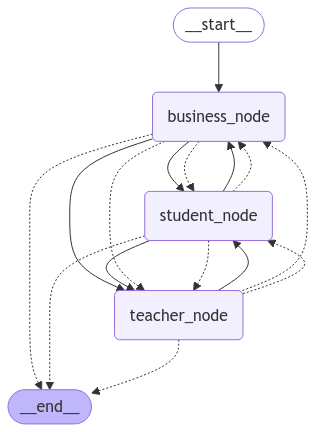

In [4]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [ ]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory  
config = {"configurable": {"thread_id": "1", "user_id": "Lance"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="Create a problem about data structures")]

# Run the graph

for chunk in workflow.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

